In [1]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning
import warnings

UCI dataset id=357. Room occupancy.
Parameters:
* date
* Temperature (C)
* Humidity
* Light (Lux)
* CO2 (ppm)
* Humidity Ratio (kg water / kg air)

Target:
* Occupancy (binary)

I dropped the date column because I don't believe this is relevant to determining whether a room is occupied or not.

Dataset size
* Number observations: 20,559 (after dropping observations with NaNs)
* Number parameters (after dropping date): 5

In [2]:
# fetch dataset
data_id=357
data_frame = fetch_ucirepo(id=data_id) 
  
# data (as pandas dataframes) 
X = data_frame.data.features
y = data_frame.data.targets
df = pd.concat([X, y], axis=1)
df = df.drop(columns=['date'])

In [3]:
df = df.to_numpy()
M = df[:, :-1]
delete_these = np.where(np.isnan(y))
M = np.delete(M,delete_these,axis=0)
y = (np.delete(y,delete_these)).astype(int)
num_obs, params = M.shape

In [4]:
rng=np.random.default_rng(51)

def resort_data(num_pts, num_params, M, y):
    '''
    num_pts: How many data points are needed (size of training data)
    M: Entire data matrix (including y-values)'''

    # Reorder M by observation so that logit doesn't break
    y_T = np.zeros(num_pts)
    while not np.any(y_T != y_T[0]):
        indices = rng.choice(np.arange(num_obs), size=num_pts, replace=False)
        y_T = y[indices]

    M_new = np.concatenate((M[indices, :], np.delete(M, indices, axis=0)))

    # Randomly sort parameters
    param_ordering = rng.permutation(params)
    M_new = M_new[:, param_ordering]

    # Breaking down the resorted matrix
    M_TM = M_new[:num_pts, :num_params]
    M_TU = M_new[:num_pts, num_params:]
    M_PM = M_new[num_pts:, :num_params]
    M_PU = M_new[num_pts:, num_params:]
    y_P = np.delete(y, indices)
    y_new = np.concatenate((y_T, y_P))
    return M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new

10.544812633470311
2.8922869079296
3.4067480190895276
0.6390486643106522
0.3814179976286931
0.06609727939668729
0.06089943607211881
0.05487099047275879
0.5404818505394297
0.3706039934046251
0.41699235942012997
0.05818466163572601
0.5410834505154225
0.3702989654185211
0.37023368673626206
0.05463066880119625
0.0659427394818661
0.41673415578134754
0.3340971116882347
0.3340880050824296
0.5404973277182445
0.37026765007511026
0.334197514508473
0.05821482089428923
0.06571017497730902
0.4254231506879334
0.054541524042568706
0.057706804840979294
0.06568700540626139
0.5394652689975321
0.05761408443546598
0.0546012044800197
0.5404747088622157
0.42545362404285436
0.06000207855718213
0.05455692149817579
0.3813208770255858
0.3812382142238251
0.05452554424230649
0.05796308327537632
0.5404766688238505
0.059974235542211735
0.05997313359894853
0.3339977598943324


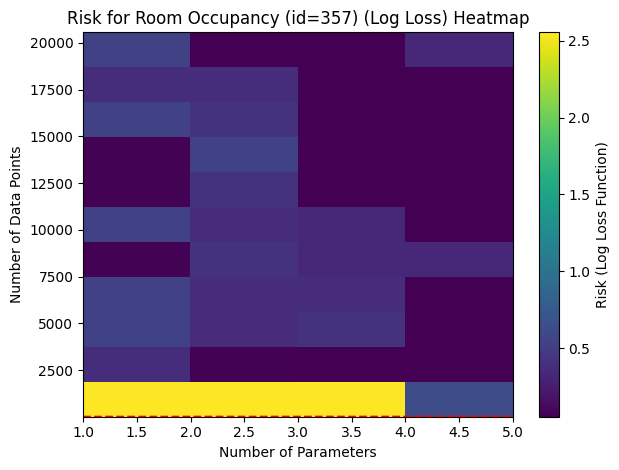

In [5]:
error_matrix = []

# Compute log loss (risk)
for j in range(2,num_obs,2000):
    error_matrix.append([])
    # y_value_labels.append(j)
    for i in range(1,params):
        model=LogisticRegression(C=np.inf,solver='lbfgs')
        M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new = resort_data(j, i, M, y)
        model.fit(M_TM, y_T)
        y_hat = model.predict_proba(np.concatenate((M_TM,M_PM)))[:, 1]
        error = log_loss(y_new, y_hat, labels=[0,1])
        error_matrix[-1].append(np.mean(error))
        print(error)
    
error_matrix = np.array(error_matrix)

# Clip to 95th percentile
p95 = np.percentile(error_matrix, 95)
error_matrix = np.clip(error_matrix, a_min=0, a_max=p95)

# Plotting it
fig, ax = plt.subplots()
yeet=ax.imshow(error_matrix, aspect='auto', origin='lower', extent = [1,params,2,num_obs])
plt.xlabel("Number of Parameters")
plt.ylabel("Number of Data Points")
plt.title(f'Risk for Room Occupancy (id={data_id}) (Log Loss) Heatmap')
fig.colorbar(yeet,label='Risk (Log Loss Function)')
plt.plot([1,min(num_obs,params)],[1,min(num_obs,params)],'--',color='red')
plt.ylim((2,num_obs))
plt.xlim((1,params))
plt.tight_layout()
plt.savefig(f'logit_risk_{data_id}.png',dpi=400)
plt.show()

The cell below does the same process, but does performs logit 10 times per `(num_obs,param)` combination and takes the average.

c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


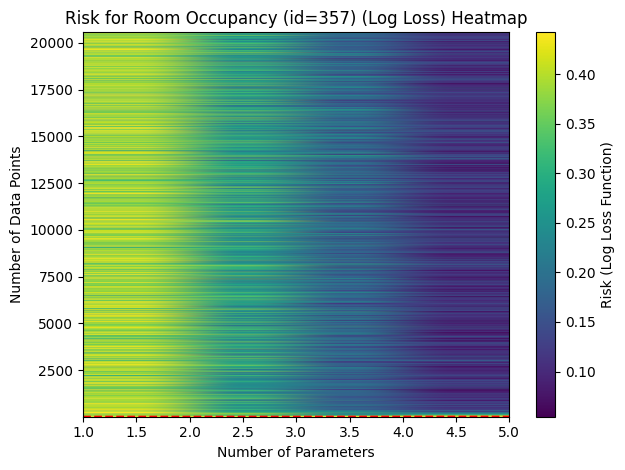

In [ ]:
error_matrix = []

# Compute log loss (risk)
for j in range(2,num_obs,15):
    error_matrix.append([])
    # y_value_labels.append(j)
    for i in range(1,params):
        listy = []
        for k in range(10):
            model=LogisticRegression(C=np.inf,solver='lbfgs')
            M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new = resort_data(j, i, M, y)
            model.fit(M_TM, y_T)
            y_hat = model.predict_proba(np.concatenate((M_TM,M_PM)))[:, 1]
            error = log_loss(y_new, y_hat, labels=[0,1])
            listy.append(error)
        listy = np.array(listy)
        error_matrix[-1].append(np.mean(listy))
    
error_matrix = np.array(error_matrix)

# Clip to 95th percentile
p95 = np.percentile(error_matrix, 95)
error_matrix = np.clip(error_matrix, a_min=0, a_max=p95)

# Plotting it
fig, ax = plt.subplots()
yeet=ax.imshow(error_matrix, aspect='auto', origin='lower', extent = [1,params,2,num_obs])
plt.xlabel("Number of Parameters")
plt.ylabel("Number of Data Points")
plt.title(f'Risk for Room Occupancy (id={data_id}) (Log Loss) Heatmap')
fig.colorbar(yeet,label='Risk (Log Loss Function)')
plt.plot([1,min(num_obs,params)],[1,min(num_obs,params)],'--',color='red')
plt.ylim((2,num_obs))
plt.xlim((1,params))
plt.tight_layout()
plt.savefig(f'logit_risk_{data_id}_10times.png',dpi=400)
plt.show()